# KND_04 - Step 4: Understand the training data

## What is EDA?

EDA means **exploratory data analysis**. We look at the data, draw charts and record what needs attention before deciding how to prepare it for models.

Here we use only the **6,096 training records** from Notebook 3. Validation and test outcomes remain reserved for later evaluation. The findings describe this selected training group, not every animal in the original dataset or all shelters.

We will answer six questions:

1. Which arrival details are missing or recorded as unknown?
2. How many stays are short or long?
3. Do the animal types have different observed long-stay percentages?
4. Do the recorded ages make sense?
5. How do arrival counts vary over time?
6. What patterns appear among the most common breeds?

These are observations, not causes or measured model results. We do not train models or permanently clean the data here.

## How to run

Keep **step3_results** beside the notebook. In Colab, run Notebook 3 first, or upload **train_records.csv** and **split_notes.json** together. Run the code cells from top to bottom.

Libraries needed: pandas and matplotlib. If an import fails in your notebook environment, run `%pip install pandas matplotlib` in a separate cell, restart the kernel if prompted, and run again.

Source: [County of Sonoma, Animal Shelter Intake and Outcome](https://data.sonomacounty.ca.gov/Government/Animal-Shelter-Intake-and-Outcome/924a-vesw), California, USA. Our saved extract was downloaded on 15 September 2026. One row represents a shelter admission.

In [1]:
from pathlib import Path
import hashlib
import json
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path("step3_results"), Path("outputs") / "step3_results",
              Path("/content/step3_results"), Path("."), Path("/content")]
STEP3_DIR = next((p.resolve() for p in candidates
                  if (p / "train_records.csv").exists()
                  and (p / "split_notes.json").exists()), None)
if STEP3_DIR is None:
    raise FileNotFoundError("Run Notebook 3 first, or upload train_records.csv AND split_notes.json.")

TRAIN_PATH = STEP3_DIR / "train_records.csv"
source_hash = hashlib.sha256(TRAIN_PATH.read_bytes()).hexdigest()
split_notes = json.loads((STEP3_DIR / "split_notes.json").read_text(encoding="utf-8"))
assert source_hash == split_notes["output_sha256"]["train_records.csv"], "File changed: check or rerun Notebook 3."

df = pd.read_csv(TRAIN_PATH, dtype={"id": "string", "impound_number": "string"})
assert len(df) == split_notes["training_rows"] == 6096
assert df["final_split"].eq("train").all()
assert df["source_row_number"].is_unique
assert df["long_stay_30"].isin([0, 1]).all()

PROJECT_DIR = STEP3_DIR.parent if STEP3_DIR.name == "step3_results" else STEP3_DIR
RESULTS_DIR = PROJECT_DIR / "step4_results"
RESULTS_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})

def save_chart(fig, filename):
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print("Training records:", len(df))
print("Charts and summaries will save in:", RESULTS_DIR)
print("Validation and test CSVs are not loaded by this notebook.")

Training records: 6096
Charts and summaries will save in: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step4_results
Validation and test CSVs are not loaded by this notebook.


## 1. What columns are we considering?

We have **11 candidate arrival fields**. These are candidates, not the final approved model inputs. Birth date will help us calculate age, and intake date may give us month or season information.

We must check whether details such as sex/neuter status or size were available at arrival or updated later. Prediction inputs must be information staff would actually have when an animal arrives.

The other columns include outcomes, identifiers and our checking columns. They can help with auditing, but should not automatically be used as model inputs.

In [2]:
CANDIDATE_FIELDS = ["type", "breed", "color", "sex", "size", "date_of_birth",
                    "intake_date", "intake_type", "intake_subtype",
                    "intake_condition", "intake_jurisdiction"]
assert set(CANDIDATE_FIELDS).issubset(df.columns)

column_summary = pd.DataFrame({
    "field": CANDIDATE_FIELDS,
    "loaded_type": [str(df[c].dtype) for c in CANDIDATE_FIELDS],
    "different_nonblank_values": [df[c].nunique(dropna=True) for c in CANDIDATE_FIELDS]
})
print(column_summary.to_string(index=False))
column_summary.to_csv(RESULTS_DIR / "candidate_columns.csv", index=False)
print("\nA date may load as text. We will read it as a date before calculating age.")

              field loaded_type  different_nonblank_values
               type         str                          3
              breed         str                        462
              color         str                        211
                sex         str                          5
               size         str                          7
      date_of_birth         str                       2094
        intake_date         str                        829
        intake_type         str                          6
     intake_subtype         str                         22
   intake_condition         str                          5
intake_jurisdiction         str                         12

A date may load as text. We will read it as a date before calculating age.


## 2. Missing and unknown values

A blank birth date means we cannot calculate that animal's age directly. The word **UNKNOWN** is different from a blank cell, but also tells us information is unavailable.

We count both separately. The checks below recognise `UNKNOWN`, `UNK`, `UNSPECIFIED` and `NOT RECORDED` as explicit unknown markers. Other unusual categories must be reviewed rather than automatically treated as missing.

**Decision to discuss:** keep useful records with missing birth dates and handle age in Notebook 5. Do not delete every row with missing information. Replacement ages must be learned from training data only.

              field  blank_count  unknown_count  unavailable_percent
               type            0              0                 0.00
              breed            0              0                 0.00
              color            0              0                 0.00
                sex            0            553                 9.07
               size            0              0                 0.00
      date_of_birth         1383              0                22.69
        intake_date            0              0                 0.00
        intake_type            0              0                 0.00
     intake_subtype            0              0                 0.00
   intake_condition            0           4468                73.29
intake_jurisdiction            0              2                 0.03
Explain: which field has the most unavailable information, and how might that limit its usefulness?


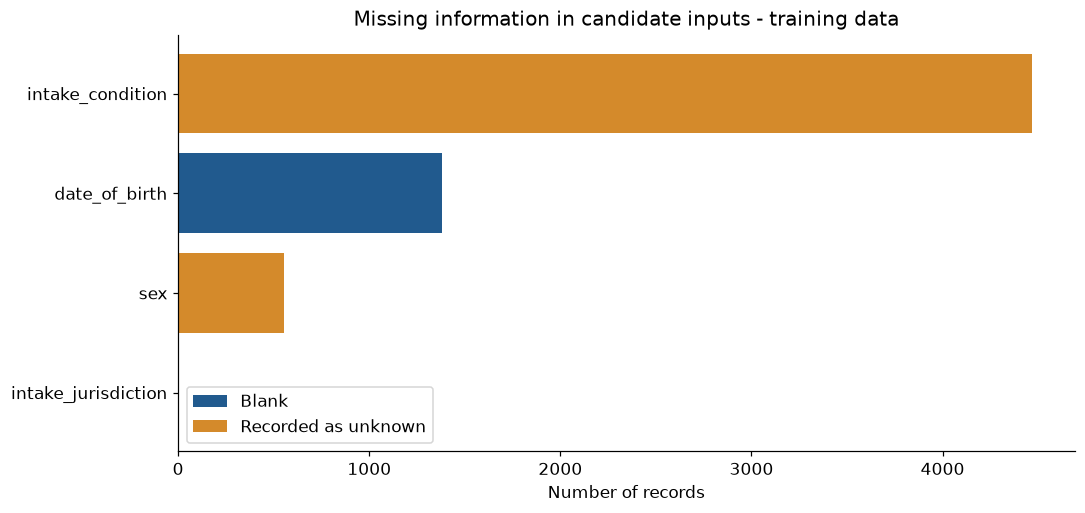

In [3]:
UNKNOWN_MARKERS = {"UNKNOWN", "UNK", "UNSPECIFIED", "NOT RECORDED"}
missing_rows = []
for field in CANDIDATE_FIELDS:
    values = df[field].astype("string").str.strip()
    blank = values.isna() | values.eq("").fillna(False)
    unknown = values.str.upper().isin(UNKNOWN_MARKERS)
    missing_rows.append({"field": field, "blank_count": int(blank.sum()),
                         "unknown_count": int(unknown.sum()),
                         "unavailable_percent": round(100 * (blank | unknown).sum() / len(df), 2)})
missing_summary = pd.DataFrame(missing_rows)
print(missing_summary.to_string(index=False))
missing_summary.to_csv(RESULTS_DIR / "missing_and_unknown.csv", index=False)

shown = missing_summary.loc[missing_summary["unavailable_percent"] > 0].copy()
shown = shown.sort_values("unavailable_percent")
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(shown["field"], shown["blank_count"], color="#215a8e", label="Blank")
ax.barh(shown["field"], shown["unknown_count"], left=shown["blank_count"],
        color="#d48a2b", label="Recorded as unknown")
ax.set(title="Missing information in candidate inputs - training data", xlabel="Number of records")
ax.legend()
save_chart(fig, "01_missing_information.png")
print("Explain: which field has the most unavailable information, and how might that limit its usefulness?")

## 3. Check repeated records

Our generated row number is unique, so including it in a duplicate check would hide repeated content. We check exact duplicates using the **24 original source columns** instead.

Several visits can belong to the same animal. A repeated animal ID is not automatically a duplicate. Here we count extra visits beyond each animal's first row and separately check same-animal, same-date candidates.

Notebook 2 already set aside unclear same-animal, same-date groups. This step checks the retained training data; it does not repeat those exclusions.

In [4]:
ORIGINAL_FIELDS = ["name", "type", "breed", "color", "sex", "size", "date_of_birth",
    "impound_number", "kennel_number", "id", "intake_date", "outcome_date", "days_in_shelter",
    "intake_type", "intake_subtype", "outcome_type", "outcome_subtype", "intake_condition",
    "outcome_condition", "intake_jurisdiction", "outcome_jurisdiction", "zip_code", "location", "intake_total"]
exact_duplicates = int(df.duplicated(subset=ORIGINAL_FIELDS).sum())
extra_visits = int(df.duplicated(subset=["id"]).sum())
same_date_rows = int(df.duplicated(subset=["id", "intake_date"], keep=False).sum())
print("Extra exact duplicate rows:", exact_duplicates)
print("Extra visits beyond each animal's first row:", extra_visits)
print("Rows sharing the same animal ID and intake date:", same_date_rows)
print("Do not remove legitimate separate visits just because an ID repeats.")

Extra exact duplicate rows: 0
Extra visits beyond each animal's first row: 463
Rows sharing the same animal ID and intake date: 0
Do not remove legitimate separate visits just because an ID repeats.


## 4. How many stays are short or long?

This checks **class balance**: how many examples we have of each answer.

If short stays are more common, a model that always predicts a short stay can get many answers right while missing every long stay. That is why accuracy alone will not be enough later.

This chart is a count of real training labels, not a model result. Some labels depend on the ongoing-stay assumption described in Notebook 2.

 target  records  percent
      0     4184    68.64
      1     1912    31.36
Short-stay share: 68.64 %
A rule that always predicts short stay would miss every long stay.


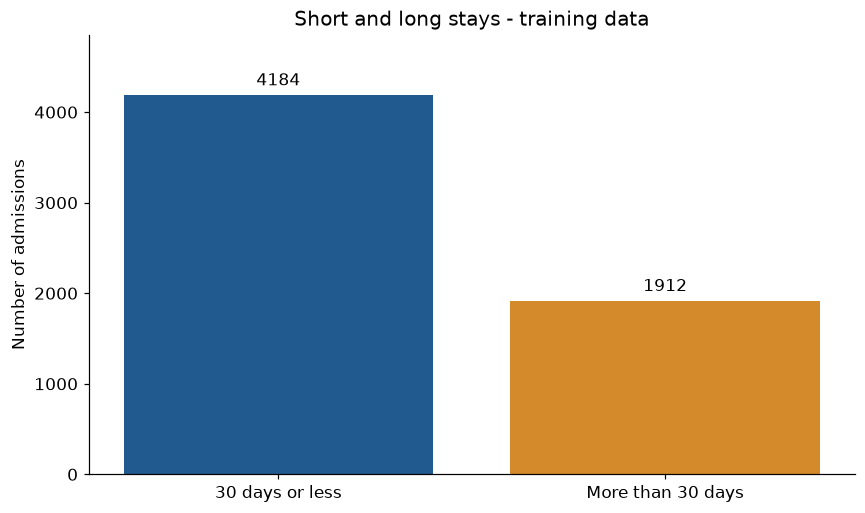

In [5]:
target_counts = df["long_stay_30"].value_counts().reindex([0, 1], fill_value=0)
target_summary = pd.DataFrame({"target": [0, 1], "records": target_counts.to_numpy(),
                               "percent": (100 * target_counts / len(df)).round(2).to_numpy()})
print(target_summary.to_string(index=False))
target_summary.to_csv(RESULTS_DIR / "target_balance.csv", index=False)
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(["30 days or less", "More than 30 days"], target_counts, color=["#215a8e", "#d48a2b"])
ax.bar_label(bars, padding=4, fmt="%.0f")
ax.set_ylim(0, target_counts.max() * 1.16)
ax.set(title="Short and long stays - training data", ylabel="Number of admissions")
save_chart(fig, "02_target_balance.png")
print("Short-stay share:", round(100 * target_counts[0] / len(df), 2), "%")
print("A rule that always predicts short stay would miss every long stay.")

## 5. Compare animal types

Look at both the **number of records** and the **percentage with long stays**. A group can have more long stays simply because it contains more animals.

The percentages are observed patterns within the training data. They do not prove that being a dog, cat or other animal causes a longer stay. The OTHER category combines different kinds of animals.

       records  long_stays  long_stay_percent
type                                         
DOG       3491         948              27.16
CAT       2000         813              40.65
OTHER      605         151              24.96


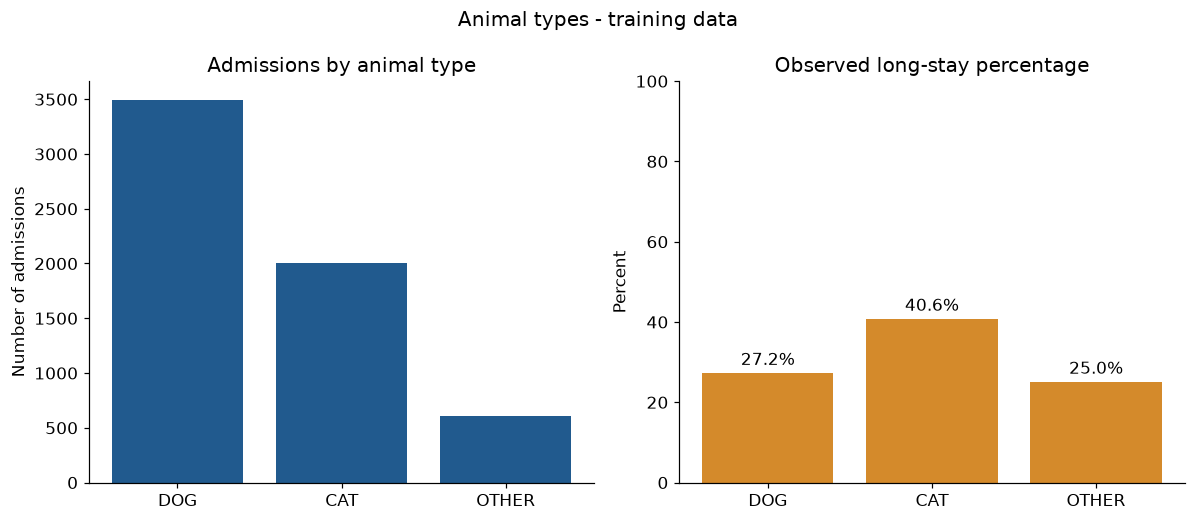

In [6]:
type_summary = df.groupby("type", dropna=False)["long_stay_30"].agg(records="size", long_stays="sum")
type_summary["long_stay_percent"] = (100 * type_summary["long_stays"] / type_summary["records"]).round(2)
type_summary = type_summary.sort_values("records", ascending=False)
print(type_summary.to_string())
type_summary.to_csv(RESULTS_DIR / "animal_type_summary.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].bar(type_summary.index.astype(str), type_summary["records"], color="#215a8e")
axes[0].set(title="Admissions by animal type", ylabel="Number of admissions")
bars = axes[1].bar(type_summary.index.astype(str), type_summary["long_stay_percent"], color="#d48a2b")
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].set(title="Observed long-stay percentage", ylabel="Percent", ylim=(0, 100))
fig.suptitle("Animal types - training data")
save_chart(fig, "03_animal_types.png")

## 6. Calculate age for exploration and check unusual dates

Age at arrival is **arrival date minus birth date**, expressed approximately in years by dividing days by 365.25. The source birth date may itself be approximate.

A birth date after arrival produces a negative age and needs attention. For this chart only, we leave invalid ages out and count them separately. We do not delete these records or fill missing ages here.

We show the full range of valid nonnegative ages. Very old ages should be reviewed by animal type. We should not remove a genuine older animal just because it is unusual.

Blank birth dates: 1383
Nonblank birth dates that cannot be read: 0
Birth dates after arrival: 11
Valid ages available for plotting: 4702

Valid age summary:
count    4702.00
mean        2.95
std         3.74
min         0.00
25%         0.25
50%         1.49
75%         4.00
max        23.30
Notebook 5: treat invalid birth dates as unavailable age, then fit age replacement using training data.


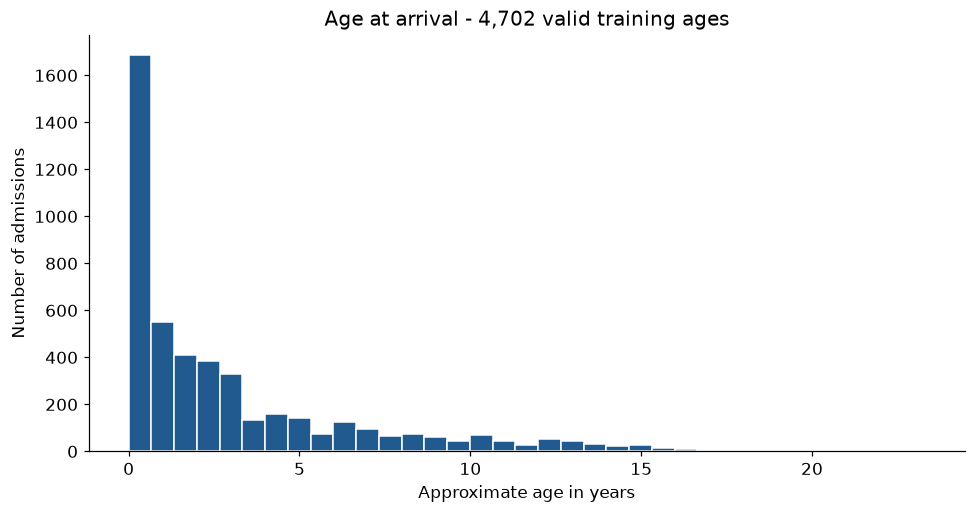

In [7]:
intake = pd.to_datetime(df["intake_date"], errors="raise")
birth = pd.to_datetime(df["date_of_birth"], errors="coerce")
birth_text = df["date_of_birth"].astype("string").str.strip()
birth_blank = birth_text.isna() | birth_text.eq("").fillna(False)
unreadable_birth = ~birth_blank & birth.isna()
age_years = (intake - birth).dt.days / 365.25
negative_age = age_years < 0
valid_age = age_years.where(age_years >= 0)

print("Blank birth dates:", int(birth_blank.sum()))
print("Nonblank birth dates that cannot be read:", int(unreadable_birth.sum()))
print("Birth dates after arrival:", int(negative_age.sum()))
print("Valid ages available for plotting:", int(valid_age.notna().sum()))
print("\nValid age summary:")
print(valid_age.describe().round(2).to_string())

age_review = df[["source_row_number", "type", "date_of_birth", "intake_date"]].copy()
age_review["age_years_for_review"] = age_years
age_review["issue"] = ""
age_review.loc[unreadable_birth, "issue"] = "Unreadable birth date"
age_review.loc[negative_age, "issue"] = "Birth date after arrival"
age_review.loc[age_review["issue"].ne("")].to_csv(RESULTS_DIR / "invalid_birth_dates_for_review.csv", index=False)
oldest = age_review.loc[valid_age.notna()].sort_values("age_years_for_review", ascending=False).head(10)
oldest.to_csv(RESULTS_DIR / "oldest_recorded_ages_for_review.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(valid_age.dropna(), bins=35, color="#215a8e", edgecolor="white")
ax.set(title=f"Age at arrival - {valid_age.notna().sum():,} valid training ages",
       xlabel="Approximate age in years", ylabel="Number of admissions")
save_chart(fig, "04_age_distribution.png")
print("Notebook 5: treat invalid birth dates as unavailable age, then fit age replacement using training data.")

## 7. Look at arrivals over time

This plot counts admissions in each calendar month of our training split. It may suggest patterns to investigate, such as months with more arrivals.

Our data covers parts of three years and excludes some earlier visits during splitting. **May 2025 is a partial month ending on 30 May.** Do not compare partial periods as if they cover the same time or claim a repeated seasonal pattern from one peak.

Describe a visible rise or fall, then explain why it does not prove a seasonal cause.


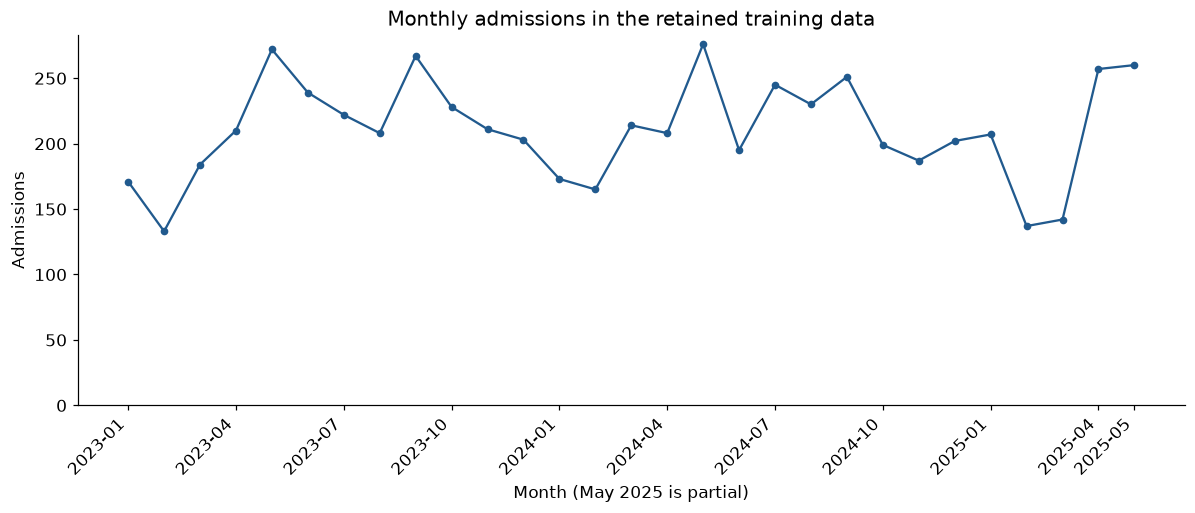

In [8]:
months = intake.dt.to_period("M")
month_range = pd.period_range(months.min(), months.max(), freq="M")
monthly = months.value_counts().reindex(month_range, fill_value=0).sort_index()
pd.DataFrame({"month": monthly.index.astype(str), "admissions": monthly.to_numpy()}).to_csv(
    RESULTS_DIR / "monthly_arrivals.csv", index=False)
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(range(len(monthly)), monthly.to_numpy(), marker="o", markersize=4, color="#215a8e")
ticks = list(range(0, len(monthly), 3))
if len(monthly) - 1 not in ticks:
    ticks.append(len(monthly) - 1)
ax.set_xticks(ticks, monthly.index.astype(str)[ticks], rotation=45, ha="right")
ax.set(title="Monthly admissions in the retained training data", ylabel="Admissions", xlabel="Month (May 2025 is partial)")
ax.set_ylim(bottom=0)
save_chart(fig, "05_monthly_arrivals.png")
print("Describe a visible rise or fall, then explain why it does not prove a seasonal cause.")

## 8. Explore common breeds without relying on tiny groups

Breed has many categories. A category with only one animal can show 0% or 100% long stays, which is weak evidence for a general pattern.

For a readable chart, we show up to **10 most frequent breed labels**, each with **at least 30 training records**. This is only a display choice, not a rule for removing records or a statistical guarantee. Later we can decide how to group rare categories using training data.

These labels can include mixed breeds and different animal types. The percentages are descriptive; differences could reflect age, intake reason or other factors.

Different breed labels: 462
Breed labels with fewer than 10 records: 392
A high percentage in a small group is not enough to make a strong claim.


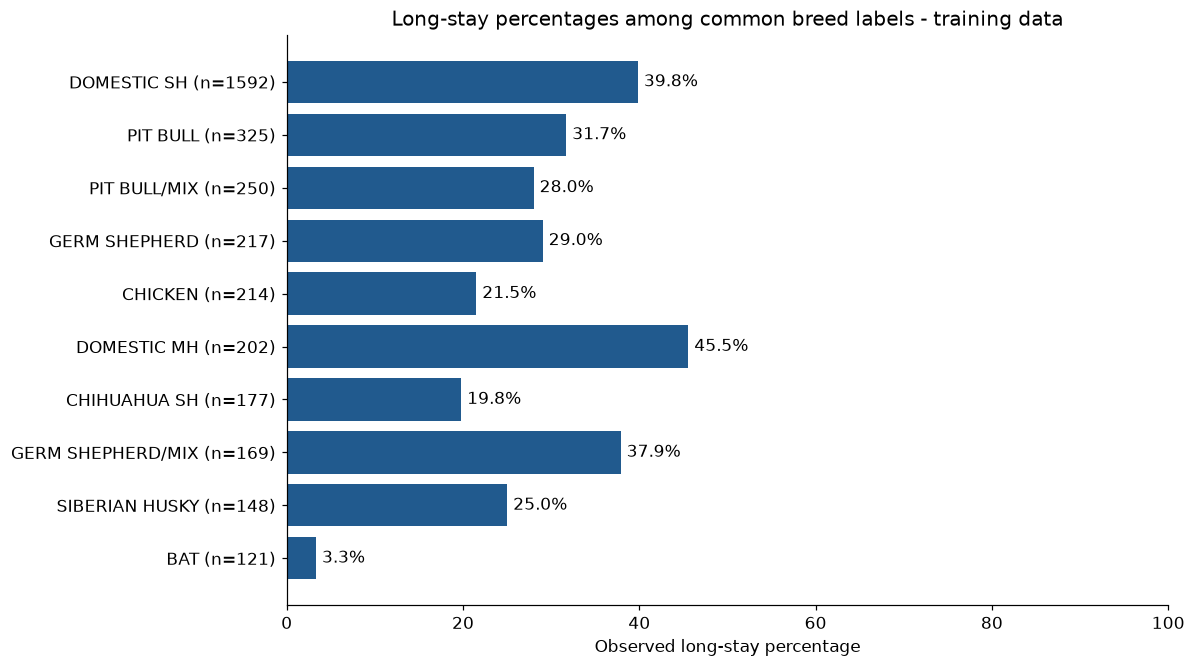

In [9]:
breed_summary = df.groupby("breed", dropna=False)["long_stay_30"].agg(records="size", long_stays="sum")
breed_summary["long_stay_percent"] = 100 * breed_summary["long_stays"] / breed_summary["records"]
breed_summary = breed_summary.sort_values("records", ascending=False)
breed_summary.to_csv(RESULTS_DIR / "breed_summary.csv")
common_breeds = breed_summary.loc[breed_summary["records"] >= 30].head(10).sort_values("records")
labels = [f"{name} (n={row.records:.0f})" for name, row in common_breeds.iterrows()]
fig, ax = plt.subplots(figsize=(11, 6.2))
bars = ax.barh(labels, common_breeds["long_stay_percent"], color="#215a8e")
ax.bar_label(bars, fmt="%.1f%%", padding=4)
ax.set(title="Long-stay percentages among common breed labels - training data",
       xlabel="Observed long-stay percentage", xlim=(0, 100))
save_chart(fig, "06_common_breeds.png")
print("Different breed labels:", df["breed"].nunique(dropna=True))
print("Breed labels with fewer than 10 records:", int((breed_summary["records"] < 10).sum()))
print("A high percentage in a small group is not enough to make a strong claim.")

## 9. Review categories before deciding how to encode them

Check the actual category labels. For example, `KITTN` and `PUPPY` describe a life stage, so the size field is not a simple small-to-large ranking. Sex may include neuter/spay status that could have changed during the stay.

Keep these issues in your decision notes. Do not choose an encoding just because every category can be replaced with a number. We still need to review what was known at arrival.

In [10]:
category_rows = []
for field in ["sex", "size", "intake_type", "intake_subtype", "intake_condition", "intake_jurisdiction"]:
    counts = df[field].fillna("(blank)").value_counts()
    print("\n" + field)
    print(counts.head(12).to_string())
    for category, count in counts.items():
        category_rows.append({"field": field, "category": category, "records": int(count)})
pd.DataFrame(category_rows).to_csv(RESULTS_DIR / "category_counts.csv", index=False)
print("\nDiscuss which categories need meaning or arrival-time checks before modelling.")


sex
sex
Neutered    1502
Male        1486
Spayed      1300
Female      1255
Unknown      553

size
size
SMALL    2300
MED      1410
KITTN     947
LARGE     729
PUPPY     490
TOY       179
X-LRG      41

intake_type
intake_type
STRAY              4343
CONFISCATE          849
OWNER SURRENDER     447
QUARANTINE          251
BORN HERE           105
ADOPTION RETURN     101

intake_subtype
intake_subtype
OVER THE COUNTER    2366
FIELD               1518
FLD_STRAY           1140
FLD_ARREST           263
FLD_HOSPTL           141
EMAIL                112
MOM STRAY            102
FLD_CRUEL             97
FLD_INVEST            94
FLD_ABAND             85
FLD_CORONR            50
FLD_EVICT             46

intake_condition
intake_condition
UNKNOWN                 4468
HEALTHY                 1411
TREATABLE/REHAB          119
TREATABLE/MANAGEABLE      61
UNTREATABLE               37

intake_jurisdiction
intake_jurisdiction
SANTA ROSA       3516
COUNTY           2401
WINDSOR            54
HEALDSBURG

## 10. Save a short findings record

This saves the measured counts and checks. It does not claim that preprocessing or model training is complete.

The output folder contains **six PNG charts**, CSV summaries, date-review lists and `eda_notes.json`. Running the notebook again replaces these generated outputs. The training CSV stays unchanged.

Charts can support the report, but each needs your own explanation: what it shows, why it matters, and what decision it suggests.

In [11]:
eda_notes = {
    "source_url": split_notes["source_url"],
    "training_csv_sha256": source_hash,
    "training_rows": len(df),
    "short_stays": int(target_counts[0]), "long_stays": int(target_counts[1]),
    "long_stay_percent": round(100 * target_counts[1] / len(df), 2),
    "blank_birth_dates": int(birth_blank.sum()),
    "unreadable_birth_dates": int(unreadable_birth.sum()),
    "birth_dates_after_intake": int(negative_age.sum()),
    "valid_nonnegative_ages": int(valid_age.notna().sum()),
    "exact_duplicate_rows": exact_duplicates,
    "extra_visits_beyond_first_per_animal": extra_visits,
    "same_animal_same_date_rows": same_date_rows,
    "candidate_fields": CANDIDATE_FIELDS,
    "different_breed_labels": int(df["breed"].nunique()),
    "rows_changed_or_removed": 0,
    "charts": sorted(p.name for p in RESULTS_DIR.glob("*.png")),
    "status": "Training-data EDA complete for these checks; preprocessing and modelling remain unfinished.",
    "next_decisions": [
        "Treat invalid ages as unavailable and fit replacement values on training data only.",
        "Review rare categories and choose train-fitted encoding.",
        "Review arrival-time availability of animal attributes before selecting final inputs.",
        "Handle imbalance during training and evaluate with more than accuracy.",
        "Keep legitimate repeated admissions and apply group/time-aware checks during tuning."
    ],
    "limitations": [
        "Patterns describe the selected training admissions and do not establish causes.",
        "Birth dates may be approximate and recorded attributes may have been updated later.",
        "Ongoing-stay label assumptions and retrospective snapshot limitations still apply.",
        "Monthly counts reflect exclusions and a partial final month.",
        "No validation or test outcome exploration was performed."
    ],
    "libraries": {"pandas": pd.__version__, "matplotlib": __import__("matplotlib").__version__}
}
assert len(df) == 6096
assert int(target_counts.sum()) == len(df)
assert int(type_summary["records"].sum()) == len(df)
assert int(monthly.sum()) == len(df)
assert int(birth_blank.sum() + unreadable_birth.sum() + negative_age.sum() + valid_age.notna().sum()) == len(df)
assert len(eda_notes["charts"]) == 6
assert hashlib.sha256(TRAIN_PATH.read_bytes()).hexdigest() == source_hash
(RESULTS_DIR / "eda_notes.json").write_text(json.dumps(eda_notes, indent=2), encoding="utf-8")
print("EDA checks passed. Training CSV unchanged.")
print("Saved six charts and supporting summaries in:", RESULTS_DIR)

EDA checks passed. Training CSV unchanged.
Saved six charts and supporting summaries in: C:\Users\ishin\Documents\Codex\2026-09-15\we-x20\outputs\step4_results


## Your group task

- **Member 1:** explain the target chart and why accuracy alone can mislead.
- **Member 2:** explain missing values and two charts of their choice.
- **Member 3:** explain the age problems and proposed preprocessing decisions.
- **Member 4:** rerun the notebook and check the saved outputs and training-file fingerprint.

Everyone should explain one observation in their own words. Record actual contributions and changes.

### Fill in these four short notes

1. **We found:** ...
2. **This matters because:** ...
3. **Our proposed action is:** ...
4. **A limitation is:** ...

Example format: "Some birth dates are missing. This means we cannot directly calculate every animal's age. We plan to keep these records, estimate unavailable ages using training data and add an age-missing flag. The estimated age is not a confirmed birth date."

### What is next?

**Notebook 5: preprocessing and feature preparation.** We will turn the agreed decisions into reusable steps, fit them on training data and apply them consistently to later data. Progress Evaluation 1 needs both EDA and completed, justified preprocessing.

After preprocessing, the later project stages are: compare at least four models; tune and select a model; build the frontend and backend; test the system and complete the report and presentation.